# Part 2: Motor Imagery Classification

**Goal**: Classify left vs. right hand motor imagery using the PhysioNet EEG Motor Movement/Imagery Dataset.

**Core Methodology**: Band-pass filtering (mu/beta rhythms), Common Spatial Pattern (CSP) spatial filtering, and classification (LDA vs. SVM).

## Data Audit

In [25]:
# Imports & Config
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

mne.set_log_level("WARNING")

# Paths
DATA_DIR     = Path("../data/motor_imagery/eegmmidb")
RESULTS_DIR  = Path("../results")
FIGURES_DIR  = Path("../figures/part2")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Dataset Config
# Subject IDs present on disk — S001 through S109
SUBJECT_IDS = sorted([p.name for p in DATA_DIR.glob("S[0-9][0-9][0-9]") if p.is_dir()])

# Runs that contain LEFT vs RIGHT HAND IMAGERY (not movement)
#   Run 04 → Task 2: imagine left/right fist
#   Run 08 → Task 2 repeated
#   Run 12 → Task 2 repeated
IMAGERY_RUNS = [4, 8, 12]

# Event codes assigned by PhysioNet for imagery runs
#   T0 = rest baseline
#   T1 = left fist imagery
#   T2 = right fist imagery
EVENT_ID = {"rest": 1, "left": 2, "right": 3}  # MNE maps T0 → 1, T1 → 2, T2 → 3

SFREQ_EXPECTED = 160.0  # Hz — expected sampling rate for all subjects

print(f"Dataset root  : {DATA_DIR}")
print(f"Total Subjects: {len(SUBJECT_IDS)}")
print(f"Imagery runs  : {IMAGERY_RUNS}")

Dataset root  : ../data/motor_imagery/eegmmidb
Total Subjects: 109
Imagery runs  : [4, 8, 12]


In [14]:
# Sanity Check (single subject → S001, Trial run = 4)
SANITY_SUBJECT = "S001"
SANITY_RUN     = 4

edf_path = DATA_DIR / SANITY_SUBJECT / f"{SANITY_SUBJECT}R{SANITY_RUN:02d}.edf"
print(f"Loading: {edf_path}\n")

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

# Channel names
print(f"Total channels : {len(raw.ch_names)}")
print(f"Channel names  : {raw.ch_names}")

Loading: ../data/motor_imagery/eegmmidb/S001/S001R04.edf

Total channels : 64
Channel names  : ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


`Notes`:
- The sample recording contains `64 EEG channels`, which matches the official PhysioNet setup and confirms that the full electrode montage is available for later CSP analysis.

In [3]:
# Sampling frequency
print(f"Sampling freq  : {raw.info['sfreq']} Hz")
assert raw.info['sfreq'] == SFREQ_EXPECTED, (
    f"Unexpected sfreq: {raw.info['sfreq']} — expected {SFREQ_EXPECTED}"
)
print("✅ sfreq matches expected\n")

# Duration
duration_sec = raw.times[-1]
print(f"Recording duration: {duration_sec:.1f} s ({duration_sec / 60:.2f} min)")

Sampling freq  : 160.0 Hz
✅ sfreq matches expected

Recording duration: 125.0 s (2.08 min)


`Notes`:
- The recording uses a sampling frequency of `160 Hz`, exactly as expected, so the data format is consistent with the official dataset and ready for filtering and epoching.
- The run duration is about `125 seconds`, which is close to the expected `2-minute task run`.

In [4]:
# Raw event annotations (what MNE reads from the EDF)
print("Raw annotations (first 10):")
print(raw.annotations.to_data_frame().head(10))

Raw annotations (first 10):
                    onset  duration description
0 2009-08-12 16:15:00.000       4.2          T0
1 2009-08-12 16:15:04.200       4.1          T2
2 2009-08-12 16:15:08.300       4.2          T0
3 2009-08-12 16:15:12.500       4.1          T1
4 2009-08-12 16:15:16.600       4.2          T0
5 2009-08-12 16:15:20.800       4.1          T1
6 2009-08-12 16:15:24.900       4.2          T0
7 2009-08-12 16:15:29.100       4.1          T2
8 2009-08-12 16:15:33.200       4.2          T0
9 2009-08-12 16:15:37.400       4.1          T2


`Notes`:
- The raw annotations alternate between rest (T0) and imagery cues (T1/T2), which shows that the cue markers were read correctly from the EDF annotation channel.

In [5]:
# Convert annotations to MNE events and confirm T1/T2 mapping
raw.load_data(verbose=False)
events, event_id_found = mne.events_from_annotations(raw, verbose=False)

print(f"MNE event_id mapping found: {event_id_found}")
print(f"  → T1 maps to {event_id_found.get('T1', 'NOT FOUND')}  (expected 2 = left)")
print(f"  → T2 maps to {event_id_found.get('T2', 'NOT FOUND')}  (expected 3 = right)")

MNE event_id mapping found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
  → T1 maps to 2  (expected 2 = left)
  → T2 maps to 3  (expected 3 = right)


`Notes`:
- The MNE event conversion worked correctly: T1 maps to the left-hand class and T2 maps to the right-hand class, so the event labels are ready for epoch creation.

In [6]:
# Count T1 and T2 events
left_code  = event_id_found.get("T1")
right_code = event_id_found.get("T2")

n_left  = (events[:, 2] == left_code).sum()
n_right = (events[:, 2] == right_code).sum()

print(f"T1 (left)  events: {n_left}")
print(f"T2 (right) events: {n_right}")
print(f"Total imagery events: {n_left + n_right}")

if n_left != n_right:
    print("⚠️ WARNING: trial counts are imbalanced in this run!")
else:
    print("✅ Trial counts are balanced")

T1 (left)  events: 8
T2 (right) events: 7
Total imagery events: 15
⚠️ WARNING: trial counts are imbalanced in this run!


`Notes`:
- In this single run, the class counts are slightly imbalanced (8 left vs 7 right), so class balance should be checked again after combining runs 4, 8, and 12 for each subject.

`Preprocessing note`: the channel names include trailing dots such as Fc2., Fc4., Fc6., C3.., Cz.., and O1... 
<br><br>
Need to clean and standardize these names early to make make channel selection and topographic plotting easier later.

In [7]:
# All-Participant Data Audit
audit_rows = []
total_subjects = len(SUBJECT_IDS)

for i, subject in enumerate(SUBJECT_IDS, 1):
    print(f"[{i}/{total_subjects}] Processing {subject}...")
    subject_totals = {
        "participant": subject,
        "total_left": 0,
        "total_right": 0,
        "total_trials": 0,
        "runs_read": 0,
        "sfreq": None,
        "notes": []
    }

    for run in IMAGERY_RUNS:
        edf_path = DATA_DIR / subject / f"{subject}R{run:02d}.edf"

        if not edf_path.exists():
            subject_totals["notes"].append(f"R{run:02d}: FILE MISSING")
            continue

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

            if subject_totals["sfreq"] is None:
                subject_totals["sfreq"] = raw.info["sfreq"]
            
            # sfreq check
            if not np.isclose(raw.info["sfreq"], SFREQ_EXPECTED):
                subject_totals["notes"].append(
                    f"R{run:02d}: sfreq={raw.info['sfreq']} (expected {SFREQ_EXPECTED})"
                )

            # Strip trailing dots from channel names
            mne.rename_channels(raw.info, {ch: ch.rstrip(".") for ch in raw.ch_names})

            # Parse events from annotations
            events, event_id_found = mne.events_from_annotations(raw, verbose=False)

            left_code = event_id_found.get("T1")
            right_code = event_id_found.get("T2")

            n_left = int((events[:, 2] == left_code).sum()) if left_code is not None else 0
            n_right = int((events[:, 2] == right_code).sum()) if right_code is not None else 0

            if left_code is None:
                subject_totals["notes"].append(f"R{run:02d}: T1 (left) annotation missing")
            if right_code is None:
                subject_totals["notes"].append(f"R{run:02d}: T2 (right) annotation missing")

            subject_totals["total_left"] += n_left
            subject_totals["total_right"] += n_right
            subject_totals["total_trials"] += n_left + n_right
            subject_totals["runs_read"] += 1

        except Exception as e:
            subject_totals["notes"].append(f"R{run:02d}: ERROR — {str(e)[:60]}")

    subject_totals["notes"] = "; ".join(subject_totals["notes"]) if subject_totals["notes"] else "OK"
    audit_rows.append(subject_totals)

print(f"Audit complete: {len(audit_rows)} subjects processed.")

[1/109] Processing S001...
[2/109] Processing S002...
[3/109] Processing S003...
[4/109] Processing S004...
[5/109] Processing S005...
[6/109] Processing S006...
[7/109] Processing S007...
[8/109] Processing S008...
[9/109] Processing S009...
[10/109] Processing S010...
[11/109] Processing S011...
[12/109] Processing S012...
[13/109] Processing S013...
[14/109] Processing S014...
[15/109] Processing S015...
[16/109] Processing S016...
[17/109] Processing S017...
[18/109] Processing S018...
[19/109] Processing S019...
[20/109] Processing S020...
[21/109] Processing S021...
[22/109] Processing S022...
[23/109] Processing S023...
[24/109] Processing S024...
[25/109] Processing S025...
[26/109] Processing S026...
[27/109] Processing S027...
[28/109] Processing S028...
[29/109] Processing S029...
[30/109] Processing S030...
[31/109] Processing S031...
[32/109] Processing S032...
[33/109] Processing S033...
[34/109] Processing S034...
[35/109] Processing S035...
[36/109] Processing S036...
[

/var/folders/1y/fqrnl1wj2v32zp3hwv5ny6_r0000gn/T/ipykernel_63903/717020738.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
/var/folders/1y/fqrnl1wj2v32zp3hwv5ny6_r0000gn/T/ipykernel_63903/717020738.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
/var/folders/1y/fqrnl1wj2v32zp3hwv5ny6_r0000gn/T/ipykernel_63903/717020738.py:25: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


`Note`:<br>
During loading, we can see `RuntimeWarning: Limited 1 annotation(s)...`.

This simply means the metadata recorded the final "experiment end" event as lasting slightly longer than the actual EEG recording. MNE automatically truncates it to fit the data. 

Since we only care about the `T1` (left) and `T2` (right) imagination cues in the middle of the recording, this warning is harmless and we can safely ignore it.

In [10]:
# Audit Analysis
audit_df = pd.DataFrame(audit_rows)

# Basic diagnostics
audit_df["balanced_exact"] = audit_df["total_left"] == audit_df["total_right"]
audit_df["balance_diff"] = (audit_df["total_left"] - audit_df["total_right"]).abs()
audit_df["all_runs_ok"] = audit_df["runs_read"] == len(IMAGERY_RUNS)
audit_df["has_both_classes"] = (audit_df["total_left"] > 0) & (audit_df["total_right"] > 0)
audit_df["no_logged_issues"] = audit_df["notes"] == "OK"

# Final practical rule
audit_df["ready"] = (
    audit_df["all_runs_ok"] &
    audit_df["has_both_classes"] &
    audit_df["no_logged_issues"]
)

print(f"Subjects with all 3 runs OK: {audit_df['all_runs_ok'].sum()} / {len(audit_df)}")
print(f"Subjects with exact left/right balance: {audit_df['balanced_exact'].sum()} / {len(audit_df)}")
print(f"Subjects with both classes present: {audit_df['has_both_classes'].sum()} / {len(audit_df)}")
print(f"Subjects that are ready: {audit_df['ready'].sum()} / {len(audit_df)}\n")

# Show subjects that need review
problems = audit_df[~audit_df["ready"]]
if not problems.empty:
    print("=== Subjects Needing Review ===")
    print(
        problems[
            ["participant", "sfreq", "total_left", "total_right", "balance_diff", "runs_read", "notes"]
        ].to_string(index=False)
    )

# Save audit
audit_df.to_csv(RESULTS_DIR / "part2_data_audit.csv", index=False)

# Final clean list
FINAL_SUBJECTS = audit_df.loc[audit_df["ready"], "participant"].tolist()
print(f"\nFinal SUBJECT count: {len(FINAL_SUBJECTS)}")

Subjects with all 3 runs OK: 109 / 109
Subjects with exact left/right balance: 1 / 109
Subjects with both classes present: 109 / 109
Subjects that are ready: 106 / 109

=== Subjects Needing Review ===
participant  sfreq  total_left  total_right  balance_diff  runs_read                                                                                                   notes
       S088  128.0          29           28             1          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)
       S092  128.0          27           30             3          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)
       S100  128.0          18           18             0          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)

Final SUBJECT count: 106


`Notes`:
- All 109 participants were found and all three imagery runs loaded successfully.
- Every participant had both `T1` and `T2` imagery events, so no subject was missing an entire class.
- Only 3 participants (`S088`, `S092`, `S100`) were flagged because their runs were sampled at 128 Hz instead of the expected 160 Hz.
- Since the rest of the dataset uses the standard 64-channel motor imagery setup, these 3 subjects were excluded for now to keep preprocessing fully consistent across participants. 
- This leaves 106 final subjects for the first classification baseline.
- Exact left/right trial balance was rare, assuming this is not a major concern because both classes are still present for all usable subjects.

## Preprocessing & Epoch Extraction

Before scaling the pipeline to all 106 subjects, need to validate the core signal processing logic on a single subject (`S001`). This includes:
1. Loading and concatenating all 3 imagery runs into a single continuous signal.
2. Plotting the **raw PSD** as a baseline reference.
3. Applying an **8–30 Hz band-pass filter** (covers mu and beta motor imagery rhythms).
4. Plotting the **filtered PSD** to confirm frequency isolation.
5. Extracting discrete **epochs** per imagery cue with a defined baseline and classification window.

In [12]:
from mne.time_frequency import psd_array_welch

In [38]:
def _clean_channel_names(raw):
    """Remove trailing dots from channel names like C3.. -> C3."""
    rename_map = {ch: ch.rstrip(".") for ch in raw.ch_names}
    mne.rename_channels(raw.info, rename_map)

def load_subject_imagery_runs(subject_id, runs=IMAGERY_RUNS, data_dir=DATA_DIR, preload=True):
    """
    Load and concatenate runs (e.g., 4, 8, 12) for one subject.
    Keeps only EEG channels and applies a standard montage where possible.
    """
    raws = []

    for run in runs:
        edf_path = data_dir / subject_id / f"{subject_id}R{run:02d}.edf"
        if not edf_path.exists():
            raise FileNotFoundError(f"Missing file: {edf_path}")

        raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=False)
        _clean_channel_names(raw)

        # Keep only EEG channels
        raw.pick_types(eeg=True, exclude=[])

        # Attach standard 10-20 montage when names match
        montage = mne.channels.make_standard_montage("standard_1005")
        raw.set_montage(montage, match_case=False, on_missing="ignore")

        raws.append(raw)

    raw_concat = mne.concatenate_raws(raws, preload=preload, verbose=False)
    return raw_concat

def summarize_events(raw):
    """
    Read events from annotations and return left/right event mapping + counts.
    """
    events, event_id_found = mne.events_from_annotations(raw, verbose=False)

    if "T1" not in event_id_found or "T2" not in event_id_found:
        raise ValueError(f"Expected T1/T2 annotations, found: {event_id_found}")

    event_id = {
        "left": event_id_found["T1"],
        "right": event_id_found["T2"],
    }

    n_left = int((events[:, 2] == event_id["left"]).sum())
    n_right = int((events[:, 2] == event_id["right"]).sum())

    print("Annotation mapping found by MNE:")
    print(event_id_found)
    print(f"\nLeft imagery  (T1): {n_left}")
    print(f"Right imagery (T2): {n_right}")
    print(f"Total imagery trials: {n_left + n_right}")

    return events, event_id

def plot_mean_psd(raw, title, fmin=1, fmax=40, save_path=None):
    """
    Plot mean PSD across EEG channels with +/- 1 std shading.
    """
    spectrum = raw.compute_psd(
        method="welch",
        fmin=fmin,
        fmax=fmax,
        picks="eeg",
        verbose=False,
    )
    psds, freqs = spectrum.get_data(return_freqs=True)  # shape: (n_channels, n_freqs)

    psd_db = 10 * np.log10(psds)
    mean_db = psd_db.mean(axis=0)
    std_db = psd_db.std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(freqs, mean_db, linewidth=2, label="Mean PSD across EEG channels")
    ax.fill_between(freqs, mean_db - std_db, mean_db + std_db, alpha=0.25, label="±1 std")
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power Spectral Density (dB)")
    ax.set_xlim(fmin, fmax)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig

`Notes`: Assigned the MNE `standard_1005` montage after renaming PhysioNet channel labels to standard EEG names, because EEGMMIDB records 64 electrodes arranged in the international 10-10 system and `standard_1005` best matches that sensor layout.

In [62]:
SUBJECT = "S001"

raw_subject = load_subject_imagery_runs(SUBJECT)

print(f"Subject            : {SUBJECT}")
print(f"Runs loaded        : {IMAGERY_RUNS}")
print(f"Sampling frequency : {raw_subject.info['sfreq']} Hz")
print(f"EEG channels kept  : {len(raw_subject.ch_names)}")
print(f"First 10 channels  : {raw_subject.ch_names[:10]}")
print(f"Duration           : {raw_subject.times[-1] / 60:.2f} minutes")

if not np.isclose(raw_subject.info["sfreq"], SFREQ_EXPECTED):
    print(f"⚠️ Warning: sfreq is {raw_subject.info['sfreq']} Hz, expected {SFREQ_EXPECTED} Hz")

events_subject, event_id_subject = summarize_events(raw_subject)

Subject            : S001
Runs loaded        : [4, 8, 12]
Sampling frequency : 160.0 Hz
EEG channels kept  : 64
First 10 channels  : ['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1']
Duration           : 6.25 minutes
Annotation mapping found by MNE:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Left imagery  (T1): 23
Right imagery (T2): 22
Total imagery trials: 45


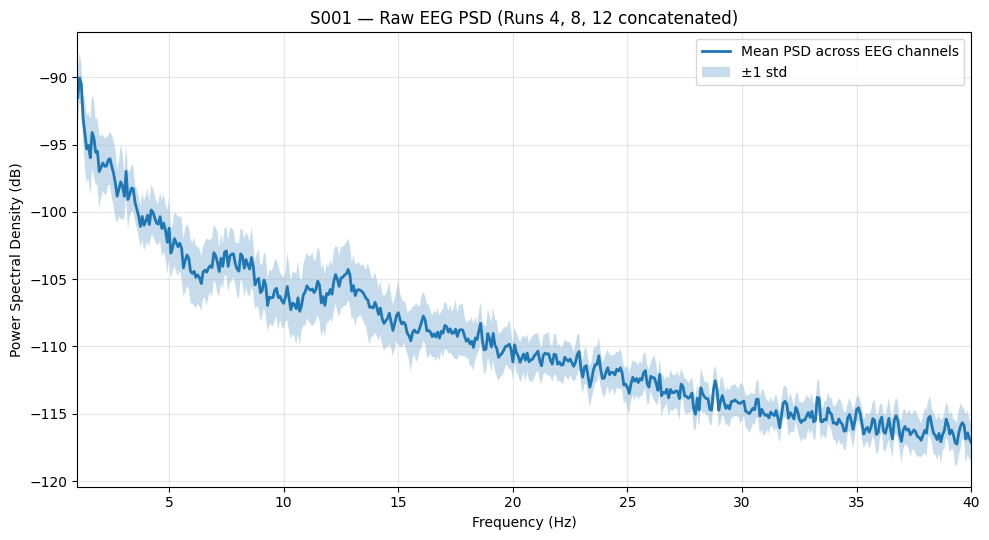

Saved raw PSD figure to: ../figures/part2/S001_pilot_raw_psd.png


In [63]:
# Raw PSD before filtering
raw_psd_path = FIGURES_DIR / f"{SUBJECT}_pilot_raw_psd.png"

plot_mean_psd(
    raw_subject,
    title=f"{SUBJECT} — Raw EEG PSD (Runs 4, 8, 12 concatenated)",
    fmin=1,
    fmax=40,
    save_path=raw_psd_path,
)

print(f"Saved raw PSD figure to: {raw_psd_path}")

### Task A: Apply 8–30 Hz band-pass filter

Saved filtered PSD figure to: ../figures/part2/S001_pilot_filtered_8_30_psd.png


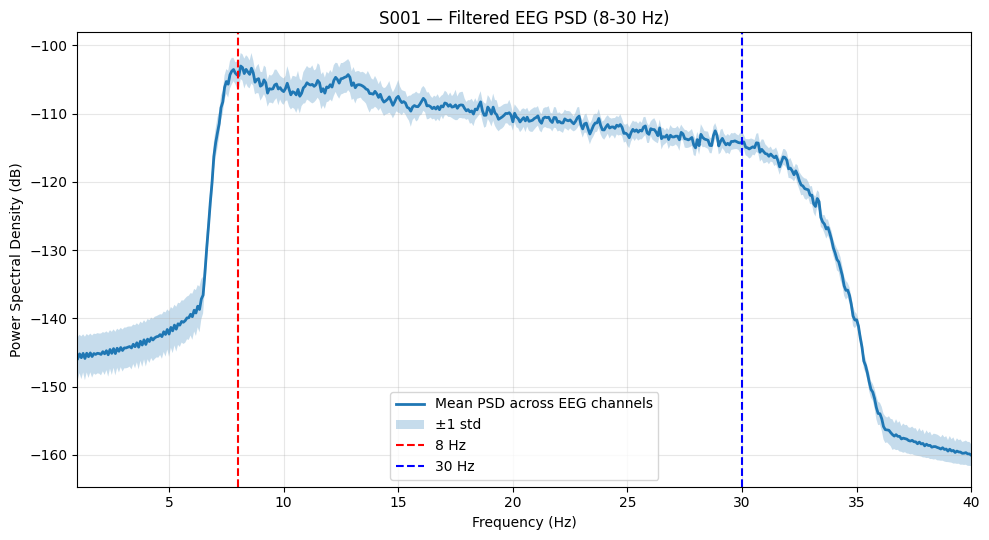

In [64]:
# Temporarily disable plt.show
original_show = plt.show
plt.show = lambda *args, **kwargs: None

fig = plot_mean_psd(
    raw_subject_filtered,
    title=f"{SUBJECT} — Filtered EEG PSD (8-30 Hz)",
    fmin=1,
    fmax=40,
    save_path=None,
)

# Restore plt.show
plt.show = original_show

ax = fig.axes[0]
ax.axvline(8, color='red', linestyle='--', linewidth=1.5, label='8 Hz')
ax.axvline(30, color='blue', linestyle='--', linewidth=1.5, label='30 Hz')

# Update legend to include new lines
ax.legend()

fig.savefig(filt_psd_path, dpi=300, bbox_inches="tight")
print(f"Saved filtered PSD figure to: {filt_psd_path}")

`Notes`:
- Successfully isolated the target frequency band. The raw signal is dominated by low-frequency noise, but the filtered PSD sharply restricts the data to the `8–30 Hz` range.

This specific range is chosen to capture two distinct sensorimotor rhythms established by [Pfurtscheller et al.](https://www.sciencedirect.com/science/article/pii/S1388245799001418) as the primary signatures of motor imagery.
1. **Mu Rhythm (8–12 Hz):** This rhythm reflects the idling state of the primary motor cortex. During motor imagery (e.g., imagining a fist clench), the mu rhythm experiences **Event-Related Desynchronization (ERD)**, appearing as a relative decrease in power.
2. **Beta Rhythm (13–30 Hz):** This band is associated with active motor concentration and typically exhibits **Event-Related Synchronization (ERS)**, or a "beta rebound" following the cessation of the motor thought.

### Task B: Epoching

In [84]:
# full epoch, baseline, and classification window
TMIN_EPOCH = -1.0
TMAX_EPOCH = 4.0
BASELINE = (-1.0, 0.0)

# Create full epochs from the filtered signal
epochs_full = mne.Epochs(
    raw_subject_filtered,
    events_subject,
    event_id=event_id_subject,
    tmin=TMIN_EPOCH,
    tmax=TMAX_EPOCH,
    baseline=BASELINE,   # baseline correction uses only -1s to 0s within each epoch
    picks="eeg",
    preload=True,
    verbose=False,
)

# Classification window: keep only 1s to 4s after cue
epochs_clf = epochs_full.copy().crop(tmin=1.0, tmax=4.0)

X_full = epochs_full.get_data()   # shape: (n_epochs, n_channels, n_samples)
X_clf = epochs_clf.get_data()
y = epochs_full.events[:, 2]

label_map = {event_id_subject["left"]: "left", event_id_subject["right"]: "right"}
y_named = pd.Series(y).map(label_map)

print("✅ Epoching complete\n")
print(f"Full epoch window: {TMIN_EPOCH:.1f}s to {TMAX_EPOCH:.1f}s")
print(f"Baseline correction window: {BASELINE}")
print("Classification window: 1.0s to 4.0s\n")

print(f"epochs_full shape: {X_full.shape}   # (n_epochs, n_channels, n_samples)")
print(f"epochs_clf shape: {X_clf.shape}   # (n_epochs, n_channels, n_samples)")
print("\nClass counts:")
print(y_named.value_counts())

✅ Epoching complete

Full epoch window: -1.0s to 4.0s
Baseline correction window: (-1.0, 0.0)
Classification window: 1.0s to 4.0s

epochs_full shape: (45, 64, 801)   # (n_epochs, n_channels, n_samples)
epochs_clf shape: (45, 64, 481)   # (n_epochs, n_channels, n_samples)

Class counts:
left     23
right    22
Name: count, dtype: int64
